# CH 5 - 4 : FALSIFYING A HYPOTHESIS WITH IMPROBABLE EVIDENCE

## Objectif pédagogique

Ce cahier transforme le concept de **falsification par évidence improbable** en démonstration concrète orientée trading/backtest.

L’idée centrale :

> On ne prouve pas directement qu’une stratégie est bonne.  
> On teste d’abord l’hypothèse inverse : **la stratégie n’a pas d’edge**.

En EBTA, cette hypothèse de départ est l’hypothèse nulle :

$$H_0 : \mu \leq 0$$

où $\mu$ représente le rendement moyen réel attendu de la stratégie.

Si le backtest produit un résultat très improbable sous $H_0$, alors on rejette $H_0$.


## 1. La logique de la falsification

La structure logique est :

1. Si $H_0$ est vraie, alors les profits observés devraient être compatibles avec le hasard.
2. Or, le backtest montre un profit très élevé.
3. Ce profit serait très rare si $H_0$ était vraie.
4. Donc $H_0$ devient difficile à défendre.
5. On la rejette si la probabilité est assez faible.

Cette probabilité s’appelle la **p-value**.

En pratique :

- p-value élevée : le profit peut facilement venir du hasard.
- p-value faible : le profit est surprenant sous $H_0$.
- p-value < 0,05 : seuil conventionnel pour rejeter $H_0$.


## 2. Exemple trading simple

Supposons une stratégie testée sur 252 jours.

Hypothèse nulle :

$$H_0 : \mu = 0$$

Cela signifie : la stratégie n’a aucun avantage moyen.

On observe pourtant un rendement annualisé de **+20 %**.

La question EBTA n’est pas :

> Est-ce que +20 % est beau ?

La vraie question est :

> Quelle est la probabilité d’obtenir +20 % ou plus si la stratégie n’a aucun edge ?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres du test
n_days = 252
n_simulations = 50_000

# Hypothèse nulle : rendement moyen journalier = 0
mu_null = 0.0

# Volatilité quotidienne supposée de la stratégie
daily_vol = 0.01  # 1 %

# Rendement annualisé observé dans le backtest
observed_annual_return = 0.20

# Conversion approximative en rendement journalier moyen observé
observed_daily_mean = observed_annual_return / 252

observed_daily_mean


0.0007936507936507937

## 3. Simuler ce que le hasard peut produire sous $H_0$

On génère plusieurs milliers de faux backtests où la stratégie n’a aucun edge.

Chaque faux backtest représente ce qui pourrait arriver uniquement par hasard si $H_0$ était vraie.


In [2]:
# Simulation de rendements sous H0
simulated_returns = np.random.normal(
    loc=mu_null,
    scale=daily_vol,
    size=(n_simulations, n_days)
)

# Moyenne quotidienne de chaque faux backtest
simulated_daily_means = simulated_returns.mean(axis=1)

# Annualisation
simulated_annual_returns = simulated_daily_means * 252

# p-value unilatérale à droite :
# probabilité d'obtenir un rendement aussi élevé ou plus élevé que l'observation
p_value = np.mean(simulated_annual_returns >= observed_annual_return)

p_value


np.float64(0.10124)

## 4. Visualiser l’évidence improbable

Si le rendement observé tombe dans l’extrême droite de la distribution simulée sous $H_0$, alors il devient une évidence improbable.

C’est exactement le cœur du raisonnement :

> Si une règle sans edge produit rarement ce résultat, alors ce résultat met $H_0$ sous pression.


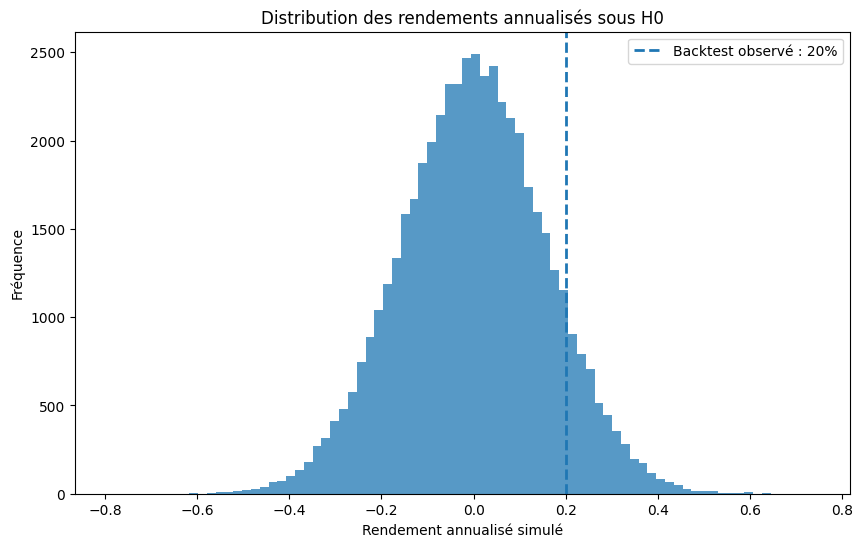

Rendement annualisé observé : 20.00%
p-value estimée : 0.1012


In [3]:
plt.figure(figsize=(10, 6))

plt.hist(simulated_annual_returns, bins=80, alpha=0.75)
plt.axvline(observed_annual_return, linestyle="--", linewidth=2, label=f"Backtest observé : {observed_annual_return:.0%}")

plt.title("Distribution des rendements annualisés sous H0")
plt.xlabel("Rendement annualisé simulé")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

print(f"Rendement annualisé observé : {observed_annual_return:.2%}")
print(f"p-value estimée : {p_value:.4f}")


## 5. Décision EBTA

Règle de décision :

$$\text{Si p-value} < 0.05, \text{ on rejette } H_0$$

Cela ne veut pas dire que la stratégie est prouvée vraie pour toujours.

Cela veut dire :

> Le résultat observé est suffisamment improbable sous l’idée que la stratégie est nulle.

Donc, l’hypothèse nulle devient moins crédible.


In [4]:
alpha = 0.05

if p_value < alpha:
    decision = "Rejet de H0 : le résultat est statistiquement surprenant sous l'hypothèse nulle."
else:
    decision = "Non-rejet de H0 : le résultat peut encore être expliqué par le hasard."

decision


'Non-rejet de H0 : le résultat peut encore être expliqué par le hasard.'

## 6. Variante : effet de la volatilité

Un même rendement de +20 % n’a pas la même force selon la volatilité de la stratégie.

- Si la stratégie est très stable, +20 % peut être très surprenant.
- Si la stratégie est très volatile, +20 % peut être banal.

La falsification dépend donc de la distance entre le résultat observé et ce que le hasard peut produire.


In [5]:
vol_levels = [0.005, 0.01, 0.02, 0.03]
results = []

for vol in vol_levels:
    sims = np.random.normal(0, vol, size=(n_simulations, n_days))
    annual_returns = sims.mean(axis=1) * 252
    pv = np.mean(annual_returns >= observed_annual_return)
    results.append({
        "Volatilité quotidienne": vol,
        "Rendement observé": observed_annual_return,
        "p-value": pv,
        "Décision": "Rejet H0" if pv < 0.05 else "Non-rejet H0"
    })

pd.DataFrame(results)


,Volatilité quotidienne,Rendement observé,p-value,Décision
0,0.005,0.2,0.00586,Rejet H0
1,0.010,0.2,0.10382,Non-rejet H0
2,0.020,0.2,0.26342,Non-rejet H0
3,0.030,0.2,0.33422,Non-rejet H0


## 7. Variante : effet du nombre de trades ou de jours

Plus l’échantillon est grand, plus la distribution d’échantillonnage devient étroite.

Donc, un même rendement moyen devient plus convaincant s’il est observé sur beaucoup de données.

C’est pourquoi un edge observé sur 50 trades n’a pas la même valeur qu’un edge observé sur 2 000 trades.


In [6]:
sample_sizes = [50, 100, 252, 500, 1000]
results_n = []

for n in sample_sizes:
    sims = np.random.normal(0, daily_vol, size=(n_simulations, n))
    annual_returns = sims.mean(axis=1) * 252
    pv = np.mean(annual_returns >= observed_annual_return)
    results_n.append({
        "Nombre de jours": n,
        "Rendement observé annualisé": observed_annual_return,
        "p-value": pv,
        "Décision": "Rejet H0" if pv < 0.05 else "Non-rejet H0"
    })

pd.DataFrame(results_n)


,Nombre de jours,Rendement observé annualisé,p-value,Décision
0,50,0.2,0.28212,Non-rejet H0
1,100,0.2,0.20980,Non-rejet H0
2,252,0.2,0.10334,Non-rejet H0
3,500,0.2,0.03822,Rejet H0
4,1000,0.2,0.00560,Rejet H0


## 8. Interprétation en mode trader EBTA

La bonne posture n’est pas :

> Ma stratégie a gagné, donc elle marche.

La bonne posture est :

> Si ma stratégie était nulle, quelle est la probabilité qu’elle produise un résultat aussi fort ?

C’est cette discipline qui protège contre :

- le biais de confirmation ;
- les narrations séduisantes ;
- les backtests chanceux ;
- les stratégies maquillées par des explications subjectives.

En EBTA, un profit n’est pas une preuve par lui-même.  
Il devient une preuve seulement s’il est **improbable sous $H_0$**.


## 9. Résumé final

À retenir :

1. On commence toujours par supposer que la stratégie est nulle.
2. On construit ou estime ce que le hasard peut produire sous cette hypothèse.
3. On compare le backtest observé à cette distribution.
4. La p-value mesure la rareté du résultat observé.
5. Si la p-value est inférieure au seuil choisi, on rejette $H_0$.
6. Rejeter $H_0$ ne prouve pas l’edge de manière absolue, mais rend l’hypothèse “pas d’edge” difficile à défendre.

Formule mentale :

> Plus le résultat est rare sous $H_0$, plus il est puissant contre $H_0$.
